Above is a binary logistic regression problem as there are only two possible outcomes (i.e. if person buys insurance or he/she doesn't). 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("HR_comma_sep.csv")

df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [4]:
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [5]:
X = df.drop('left', axis=1)

y = df['left']


In [6]:
X = pd.get_dummies(X, drop_first=True)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = LogisticRegression(max_iter=1500)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1500
,multi_class,'deprecated'


In [9]:
dataset_predictions = model.predict(X)

In [10]:
y_pred = model.predict(X_test)

y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1])

In [11]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:")
print(round(accuracy * 100,2), "%")


Accuracy:
78.23 %


In [12]:
x = np.linspace(-10,10,200)

y = 1 / (1 + np.exp(-x))

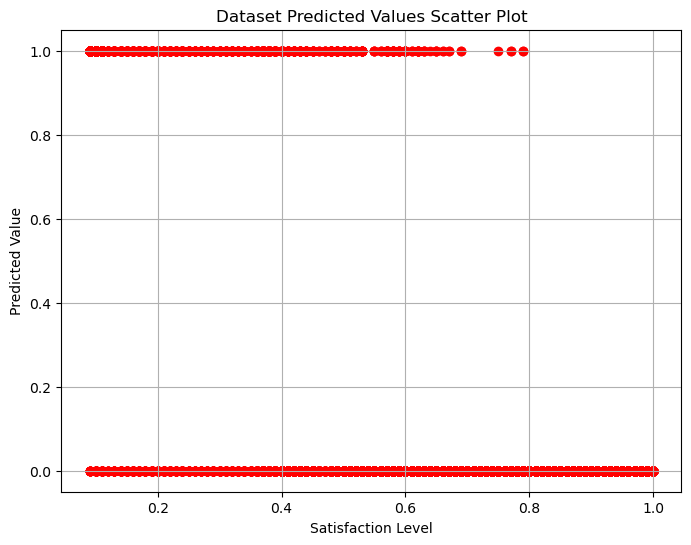

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['satisfaction_level'],
    dataset_predictions,
    color='red'
)

plt.xlabel("Satisfaction Level")
plt.ylabel("Predicted Value")

plt.title("Dataset Predicted Values Scatter Plot")

plt.grid(True)

plt.show()

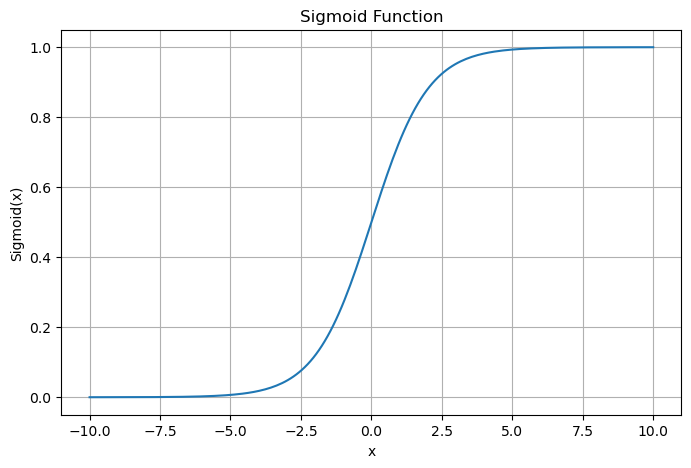

In [14]:
plt.figure(figsize=(8,5))

plt.plot(x, y)

plt.title("Sigmoid Function")
plt.xlabel("x")
plt.ylabel("Sigmoid(x)")

plt.grid(True)

plt.show()

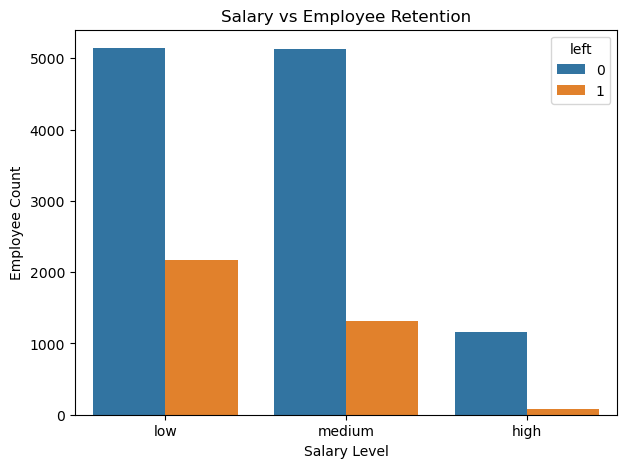

In [15]:
plt.figure(figsize=(7,5))

sns.countplot(x='salary', hue='left', data=df)

plt.title("Salary vs Employee Retention")
plt.xlabel("Salary Level")
plt.ylabel("Employee Count")

plt.show()

/home/intellect/anaconda3/envs/dsenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


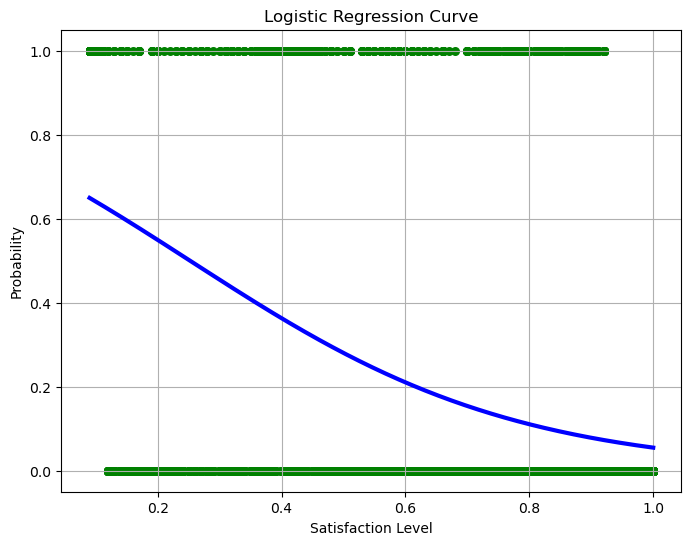

In [16]:
x = df['satisfaction_level']
y = df['left']

X_graph = df[['satisfaction_level']]
y_graph = df['left']

graph_model = LogisticRegression()

graph_model.fit(X_graph, y_graph)

x_range = np.linspace(
    x.min(),
    x.max(),
    300
).reshape(-1,1)

y_curve = graph_model.predict_proba(x_range)[:,1]

plt.figure(figsize=(8,6))

plt.plot(
    x_range,
    y_curve,
    color='blue',
    linewidth=3
)

plt.scatter(
    x,
    y,
    color='green',
    s=30
)

plt.xlabel("Satisfaction Level")
plt.ylabel("Probability")

plt.title("Logistic Regression Curve")

plt.grid(True)

plt.show()